# Notebook 09: Selection Diagnostics Comparison

This notebook compares portfolio-selection diagnostics across the benchmark and machine-learning models.

The analysis focuses on:
- average realized return of selected best stocks,
- average realized return of all stocks,
- average realized return of selected worst stocks,
- best-vs-market and best-vs-worst return gaps,
- winner-picking correctness,
- loser-picking correctness.

This analysis is designed to evaluate ranking usefulness for portfolio construction rather than raw forecast error alone.

In [1]:
from pathlib import Path
import sys

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.analysis.portfolio_selection_diagnostics import compute_monthly_selection_diagnostics
from src.utils.plotting import (
    STYLE,
    get_model_color,
    plot_equity_curve,
    plot_drawdown,
    plot_multi_series,
    plot_metric_bar,
    plot_grouped_metric_bars,
)

In [2]:
NOTEBOOK_NAME = "notebook09"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables" / NOTEBOOK_NAME
FIGURES_DIR = REPORTS_DIR / "figures" / NOTEBOOK_NAME
EXPORTS_DIR = REPORTS_DIR / "exports"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Tables dir :", TABLES_DIR)
print("Figures dir:", FIGURES_DIR)

Tables dir : C:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook09
Figures dir: C:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\figures\notebook09


In [3]:
MODEL_RESULT_DIRS = {
    "Ridge daily": PROJECT_ROOT / "experiments" / "results" / "exp02_linear_ridge_daily",
    "Ridge daily_ohlcv": PROJECT_ROOT / "experiments" / "results" / "exp02_linear_ridge_daily_ohlcv",
    "RF daily": PROJECT_ROOT / "experiments" / "results" / "exp04_random_forest_rolling_daily",
    "RF daily_ohlcv": PROJECT_ROOT / "experiments" / "results" / "exp04_random_forest_rolling_daily_ohlcv",
    "XGBoost daily": PROJECT_ROOT / "experiments" / "results" / "exp03_xgboost_rolling_daily",
    "XGBoost daily_ohlcv": PROJECT_ROOT / "experiments" / "results" / "exp03_xgboost_rolling_daily_ohlcv",
    "MLP daily": PROJECT_ROOT / "experiments" / "results" / "exp05_nn_mlp_daily",
    "MLP daily_ohlcv": PROJECT_ROOT / "experiments" / "results" / "exp05_nn_mlp_daily_ohlcv",
    "LSTM": PROJECT_ROOT / "experiments" / "results" / "exp06_lstm_daily",
}

In [4]:
def find_test_prediction_file(result_dir: Path) -> Path | None:
    candidate_names = [
        "test_predictions.csv",
        "test_predictions_2025.csv",
        "predictions_test.csv",
        "prediction_test.csv",
        "test_pred.csv",
    ]

    for name in candidate_names:
        path = result_dir / name
        if path.exists():
            return path

    csv_files = sorted(result_dir.glob("*.csv"))
    for path in csv_files:
        name = path.name.lower()
        if "test" in name and "pred" in name:
            return path

    return None


def detect_prediction_columns(df: pd.DataFrame) -> tuple[str, str]:
    pred_candidates = ["pred_return", "y_pred", "prediction", "predicted_return"]
    actual_candidates = ["y_next_1m", "y_true", "actual_return", "target"]

    pred_col = next((c for c in pred_candidates if c in df.columns), None)
    actual_col = next((c for c in actual_candidates if c in df.columns), None)

    if pred_col is None or actual_col is None:
        raise ValueError(
            f"Could not detect prediction columns.\nAvailable columns: {df.columns.tolist()}"
        )

    return pred_col, actual_col

In [5]:
resolved_prediction_paths = {}
missing_prediction_paths = {}

for model_name, result_dir in MODEL_RESULT_DIRS.items():
    pred_file = find_test_prediction_file(result_dir)
    if pred_file is not None:
        resolved_prediction_paths[model_name] = pred_file
    else:
        missing_prediction_paths[model_name] = result_dir

print("=== RESOLVED PREDICTION FILES ===")
for model_name, path in resolved_prediction_paths.items():
    print(f"{model_name}: {path.name}")

print("\n=== MISSING PREDICTION FILES ===")
for model_name, path in missing_prediction_paths.items():
    print(f"{model_name}: {path}")

=== RESOLVED PREDICTION FILES ===
Ridge daily: test_predictions.csv
Ridge daily_ohlcv: test_predictions.csv
RF daily: test_predictions.csv
RF daily_ohlcv: test_predictions.csv
XGBoost daily: test_predictions.csv
XGBoost daily_ohlcv: test_predictions.csv
MLP daily: test_predictions.csv
MLP daily_ohlcv: test_predictions.csv
LSTM: test_predictions.csv

=== MISSING PREDICTION FILES ===


In [6]:
all_spread_summaries = []
all_overlap_summaries = []
monthly_spread_results = {}
monthly_overlap_results = {}
membership_results = {}

for model_name, pred_path in resolved_prediction_paths.items():
    df = pd.read_csv(pred_path)
    pred_col, actual_col = detect_prediction_columns(df)

    monthly_spreads, spread_summary, monthly_overlap, overlap_summary, membership_df = (
        compute_monthly_selection_diagnostics(
            df=df,
            date_col="date",
            ticker_col="ticker",
            pred_col=pred_col,
            actual_col=actual_col,
            top_frac=0.20,
            bottom_frac=0.20,
            higher_is_better=True,
        )
    )

    spread_summary = spread_summary.copy()
    overlap_summary = overlap_summary.copy()
    monthly_spreads = monthly_spreads.copy()
    monthly_overlap = monthly_overlap.copy()
    membership_df = membership_df.copy()

    spread_summary["model"] = model_name
    overlap_summary["model"] = model_name
    monthly_spreads["model"] = model_name
    monthly_overlap["model"] = model_name
    membership_df["model"] = model_name

    all_spread_summaries.append(spread_summary)
    all_overlap_summaries.append(overlap_summary)

    monthly_spread_results[model_name] = monthly_spreads
    monthly_overlap_results[model_name] = monthly_overlap
    membership_results[model_name] = membership_df

In [7]:
spread_summary_df = pd.concat(all_spread_summaries, ignore_index=True)
overlap_summary_df = pd.concat(all_overlap_summaries, ignore_index=True)

selection_comparison = spread_summary_df.merge(
    overlap_summary_df,
    on=["model", "months_evaluated"],
    how="left"
)

selection_comparison = selection_comparison[
    [
        "model",
        "months_evaluated",
        "mean_top_avg_return",
        "mean_all_avg_return",
        "mean_bottom_avg_return",
        "mean_top_minus_all",
        "mean_all_minus_bottom",
        "mean_top_minus_bottom",
        "pct_months_top_gt_all",
        "pct_months_bottom_lt_all",
        "pct_months_top_gt_bottom",
        "mean_top_overlap_rate",
        "mean_bottom_overlap_rate",
    ]
].rename(
    columns={
        "mean_top_avg_return": "avg_return_selected_best_stocks",
        "mean_all_avg_return": "avg_return_all_stocks",
        "mean_bottom_avg_return": "avg_return_selected_worst_stocks",
        "mean_top_minus_all": "best_stocks_advantage_over_market_avg",
        "mean_all_minus_bottom": "market_advantage_over_worst_stocks",
        "mean_top_minus_bottom": "gap_between_best_and_worst_selected_stocks",
        "pct_months_top_gt_all": "how_often_best_picks_beat_market_avg",
        "pct_months_bottom_lt_all": "how_often_worst_picks_underperform_market_avg",
        "pct_months_top_gt_bottom": "how_often_best_picks_beat_worst_picks",
        "mean_top_overlap_rate": "winner_picking_correctness",
        "mean_bottom_overlap_rate": "loser_picking_correctness",
    }
)

selection_comparison = selection_comparison.sort_values(
    by="best_stocks_advantage_over_market_avg",
    ascending=False,
).reset_index(drop=True)

selection_comparison

,model,months_evaluated,avg_return_selected_best_stocks,avg_return_all_stocks,avg_return_selected_worst_stocks,best_stocks_advantage_over_market_avg,market_advantage_over_worst_stocks,gap_between_best_and_worst_selected_stocks,how_often_best_picks_beat_market_avg,how_often_worst_picks_underperform_market_avg,how_often_best_picks_beat_worst_picks,winner_picking_correctness,loser_picking_correctness
0,RF daily_ohlcv,11,0.034969,0.014733,0.012754,0.020237,0.001979,0.022216,0.727273,0.545455,0.727273,0.368687,0.207071
1,RF daily,11,0.034481,0.014733,0.011795,0.019748,0.002938,0.022686,0.545455,0.545455,0.545455,0.368687,0.186869
2,MLP daily,11,0.029427,0.014733,0.013305,0.014695,0.001428,0.016123,0.636364,0.545455,0.727273,0.303030,0.186869
3,XGBoost daily,11,0.029351,0.014733,0.010598,0.014618,0.004135,0.018753,0.727273,0.545455,0.818182,0.318182,0.196970
4,XGBoost daily_ohlcv,11,0.027553,0.014733,0.005482,0.012820,0.009251,0.022071,0.727273,0.636364,0.727273,0.297980,0.222222
5,Ridge daily,11,0.024695,0.014733,0.011326,0.009962,0.003407,0.013369,0.545455,0.454545,0.545455,0.297980,0.191919
6,Ridge daily_ohlcv,11,0.020166,0.014733,0.013413,0.005434,0.001319,0.006753,0.545455,0.636364,0.727273,0.277778,0.181818
7,LSTM,11,0.016693,0.014569,0.012945,0.002124,0.001623,0.003748,0.545455,0.454545,0.636364,0.191919,0.202020
8,MLP daily_ohlcv,11,0.015735,0.014733,0.018756,0.001002,-0.004024,-0.003021,0.545455,0.454545,0.454545,0.247475,0.161616


In [8]:
selection_comparison_path = TABLES_DIR / "selection_diagnostics_model_comparison.csv"
monthly_spread_path = TABLES_DIR / "monthly_selection_spreads_all_models.csv"
monthly_overlap_path = TABLES_DIR / "monthly_top_bottom_overlap_all_models.csv"
membership_path = TABLES_DIR / "monthly_group_membership_all_models.csv"

monthly_spread_all = pd.concat(monthly_spread_results.values(), ignore_index=True)
monthly_overlap_all = pd.concat(monthly_overlap_results.values(), ignore_index=True)
membership_all = pd.concat(membership_results.values(), ignore_index=True)

selection_comparison.to_csv(selection_comparison_path, index=False)
monthly_spread_all.to_csv(monthly_spread_path, index=False)
monthly_overlap_all.to_csv(monthly_overlap_path, index=False)
membership_all.to_csv(membership_path, index=False)

print("Saved:", selection_comparison_path)
print("Saved:", monthly_spread_path)
print("Saved:", monthly_overlap_path)
print("Saved:", membership_path)

Saved: C:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook09\selection_diagnostics_model_comparison.csv
Saved: C:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook09\monthly_selection_spreads_all_models.csv
Saved: C:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook09\monthly_top_bottom_overlap_all_models.csv
Saved: C:\Users\amila\OneDrive\UH\DSP\Git\stability-aware-stock-momentum-ml\reports\tables\notebook09\monthly_group_membership_all_models.csv


In [9]:
selection_comparison_display = selection_comparison.copy()

pct_cols = [
    "how_often_best_picks_beat_market_avg",
    "how_often_worst_picks_underperform_market_avg",
    "how_often_best_picks_beat_worst_picks",
    "winner_picking_correctness",
    "loser_picking_correctness",
]

for col in pct_cols:
    selection_comparison_display[col] = selection_comparison_display[col] * 100

selection_comparison_display = selection_comparison_display.round(3)
selection_comparison_display

,model,months_evaluated,avg_return_selected_best_stocks,avg_return_all_stocks,avg_return_selected_worst_stocks,best_stocks_advantage_over_market_avg,market_advantage_over_worst_stocks,gap_between_best_and_worst_selected_stocks,how_often_best_picks_beat_market_avg,how_often_worst_picks_underperform_market_avg,how_often_best_picks_beat_worst_picks,winner_picking_correctness,loser_picking_correctness
0,RF daily_ohlcv,11,0.035,0.015,0.013,0.020,0.002,0.022,72.727,54.545,72.727,36.869,20.707
1,RF daily,11,0.034,0.015,0.012,0.020,0.003,0.023,54.545,54.545,54.545,36.869,18.687
2,MLP daily,11,0.029,0.015,0.013,0.015,0.001,0.016,63.636,54.545,72.727,30.303,18.687
3,XGBoost daily,11,0.029,0.015,0.011,0.015,0.004,0.019,72.727,54.545,81.818,31.818,19.697
4,XGBoost daily_ohlcv,11,0.028,0.015,0.005,0.013,0.009,0.022,72.727,63.636,72.727,29.798,22.222
5,Ridge daily,11,0.025,0.015,0.011,0.010,0.003,0.013,54.545,45.455,54.545,29.798,19.192
6,Ridge daily_ohlcv,11,0.020,0.015,0.013,0.005,0.001,0.007,54.545,63.636,72.727,27.778,18.182
7,LSTM,11,0.017,0.015,0.013,0.002,0.002,0.004,54.545,45.455,63.636,19.192,20.202
8,MLP daily_ohlcv,11,0.016,0.015,0.019,0.001,-0.004,-0.003,54.545,45.455,45.455,24.747,16.162


In [10]:
final_color_map = {
    "Baseline Momentum": get_model_color("baseline"),
    "Ridge daily": get_model_color("ridge"),
    "Ridge daily_ohlcv": "#9C755F",
    "RF daily": get_model_color("random_forest"),
    "RF daily_ohlcv": "#8C564B",
    "XGBoost daily": get_model_color("xgboost"),
    "XGBoost daily_ohlcv": "#C5B0D5",
    "MLP daily": get_model_color("mlp"),
    "MLP daily_ohlcv": "#C49C94",
    "LSTM": get_model_color("lstm"),
}
final_color_map

{'Baseline Momentum': '#595959',
 'Ridge daily': '#4E79A7',
 'Ridge daily_ohlcv': '#9C755F',
 'RF daily': '#F28E2B',
 'RF daily_ohlcv': '#8C564B',
 'XGBoost daily': '#B07AA1',
 'XGBoost daily_ohlcv': '#C5B0D5',
 'MLP daily': '#9C755F',
 'MLP daily_ohlcv': '#C49C94',
 'LSTM': '#76B7B2'}

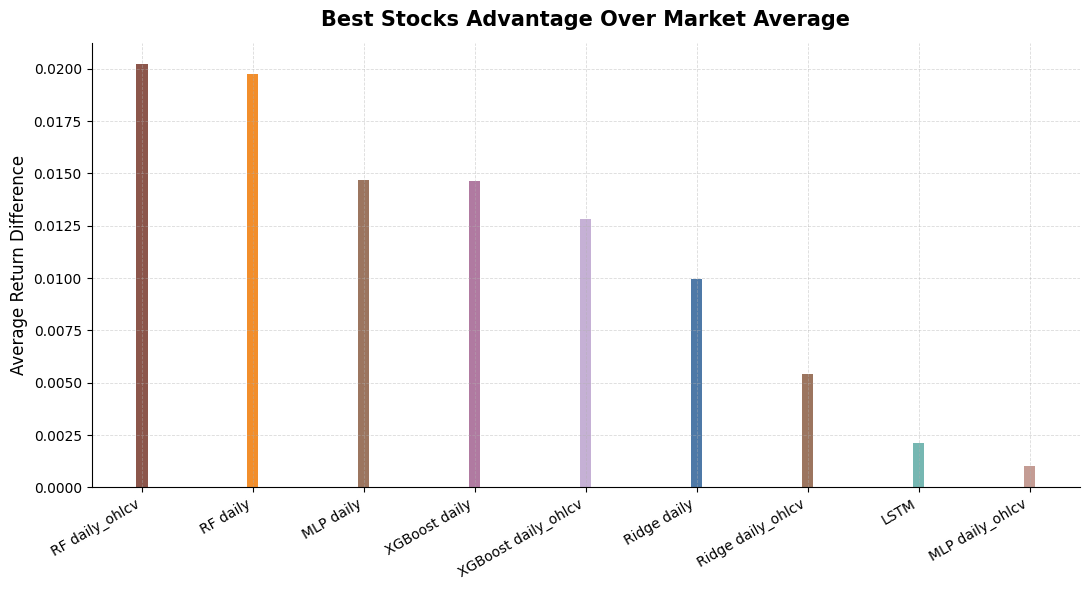

In [11]:
best_minus_market_values = selection_comparison.set_index("model")[
    "best_stocks_advantage_over_market_avg"
].sort_values(ascending=False)

plot_metric_bar(
    values=best_minus_market_values,
    title="Best Stocks Advantage Over Market Average",
    ylabel="Average Return Difference",
    save_path=str(FIGURES_DIR / "selection_best_minus_market.png"),
    color_map=final_color_map,
    show=True,
)

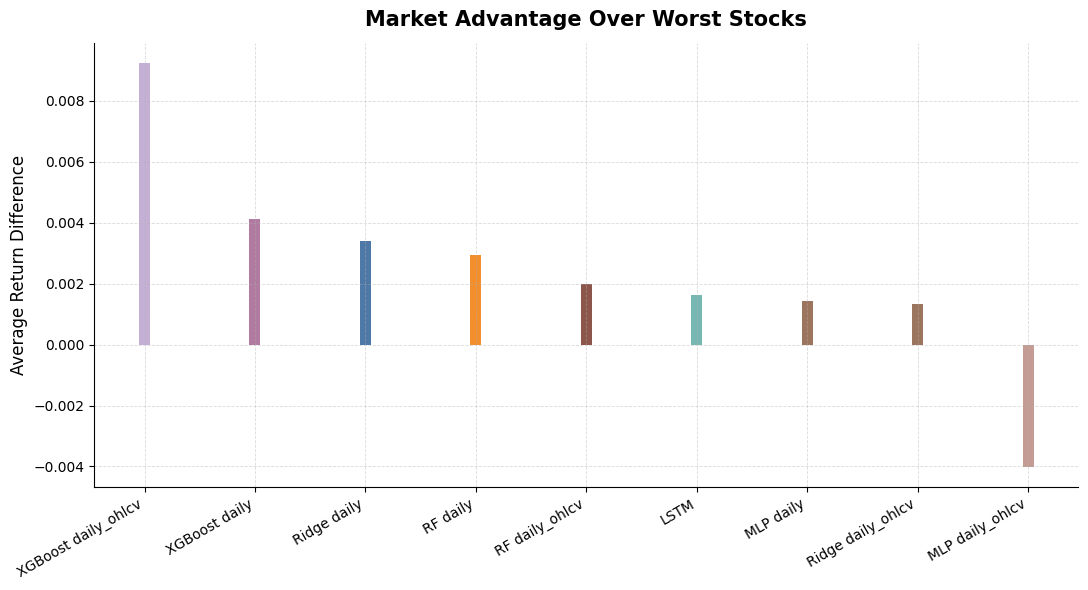

In [12]:
market_minus_worst_values = selection_comparison.set_index("model")[
    "market_advantage_over_worst_stocks"
].sort_values(ascending=False)

plot_metric_bar(
    values=market_minus_worst_values,
    title="Market Advantage Over Worst Stocks",
    ylabel="Average Return Difference",
    save_path=str(FIGURES_DIR / "selection_market_minus_worst.png"),
    color_map=final_color_map,
    show=True,
)

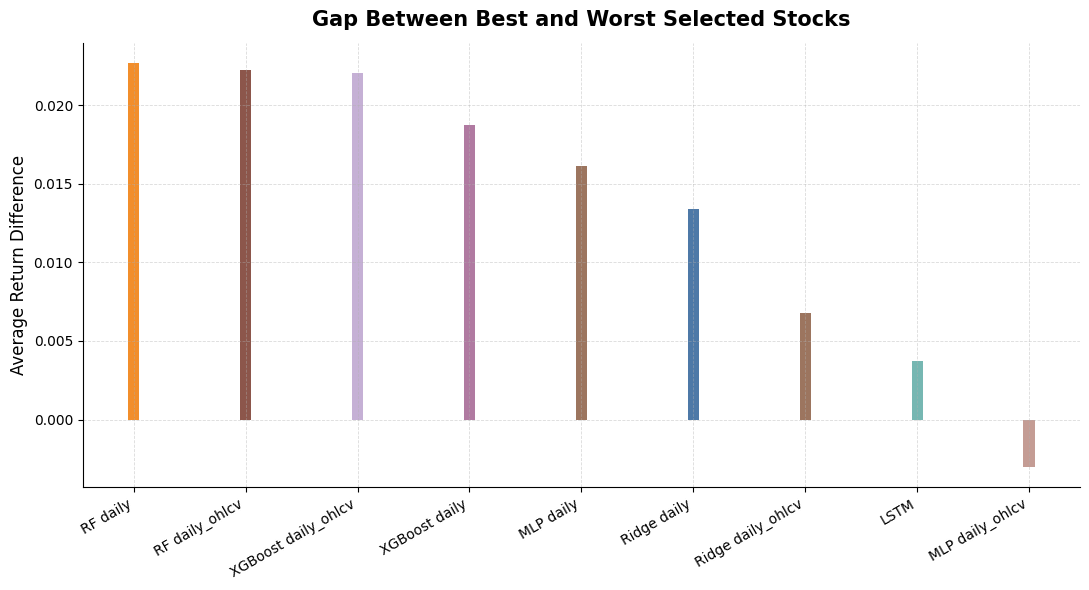

In [13]:
best_minus_worst_values = selection_comparison.set_index("model")[
    "gap_between_best_and_worst_selected_stocks"
].sort_values(ascending=False)

plot_metric_bar(
    values=best_minus_worst_values,
    title="Gap Between Best and Worst Selected Stocks",
    ylabel="Average Return Difference",
    save_path=str(FIGURES_DIR / "selection_best_minus_worst.png"),
    color_map=final_color_map,
    show=True,
)

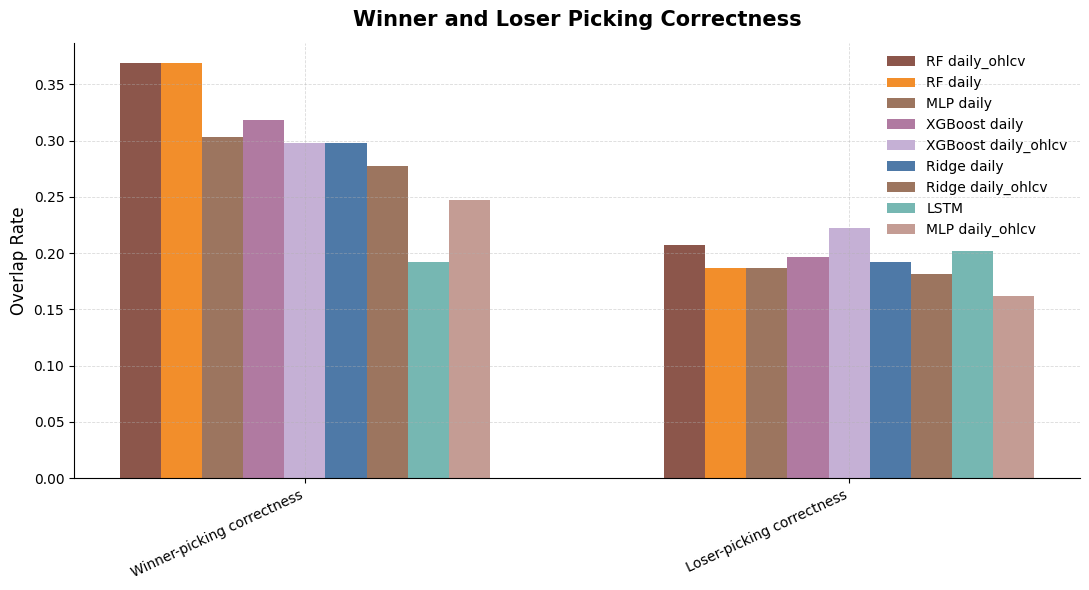

In [14]:
correctness_plot_df = pd.DataFrame(
    {
        "Winner-picking correctness": selection_comparison.set_index("model")[
            "winner_picking_correctness"
        ],
        "Loser-picking correctness": selection_comparison.set_index("model")[
            "loser_picking_correctness"
        ],
    }
).T

plot_grouped_metric_bars(
    metric_df=correctness_plot_df,
    title="Winner and Loser Picking Correctness",
    ylabel="Overlap Rate",
    save_path=str(FIGURES_DIR / "selection_correctness_grouped.png"),
    color_map=final_color_map,
    show=True,
)

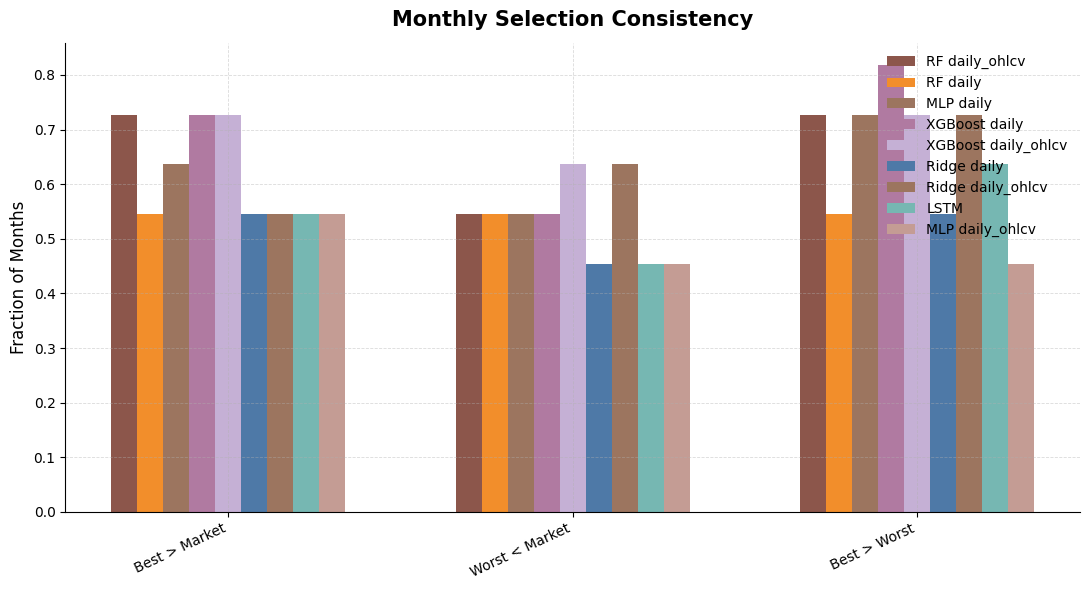

In [15]:
consistency_plot_df = pd.DataFrame(
    {
        "Best > Market": selection_comparison.set_index("model")[
            "how_often_best_picks_beat_market_avg"
        ],
        "Worst < Market": selection_comparison.set_index("model")[
            "how_often_worst_picks_underperform_market_avg"
        ],
        "Best > Worst": selection_comparison.set_index("model")[
            "how_often_best_picks_beat_worst_picks"
        ],
    }
).T

plot_grouped_metric_bars(
    metric_df=consistency_plot_df,
    title="Monthly Selection Consistency",
    ylabel="Fraction of Months",
    save_path=str(FIGURES_DIR / "selection_consistency_grouped.png"),
    color_map=final_color_map,
    show=True,
)

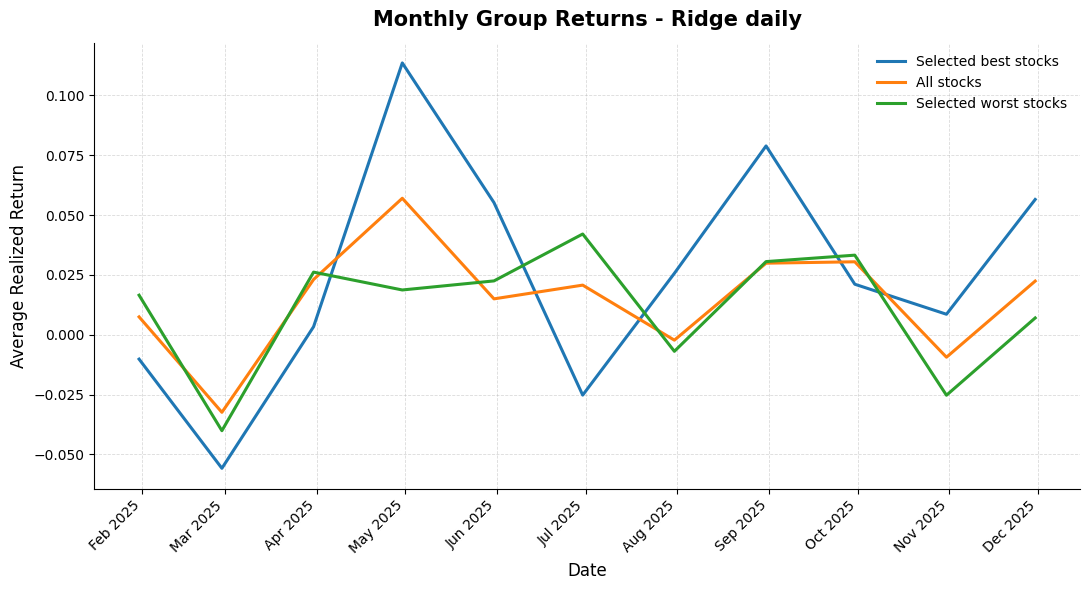

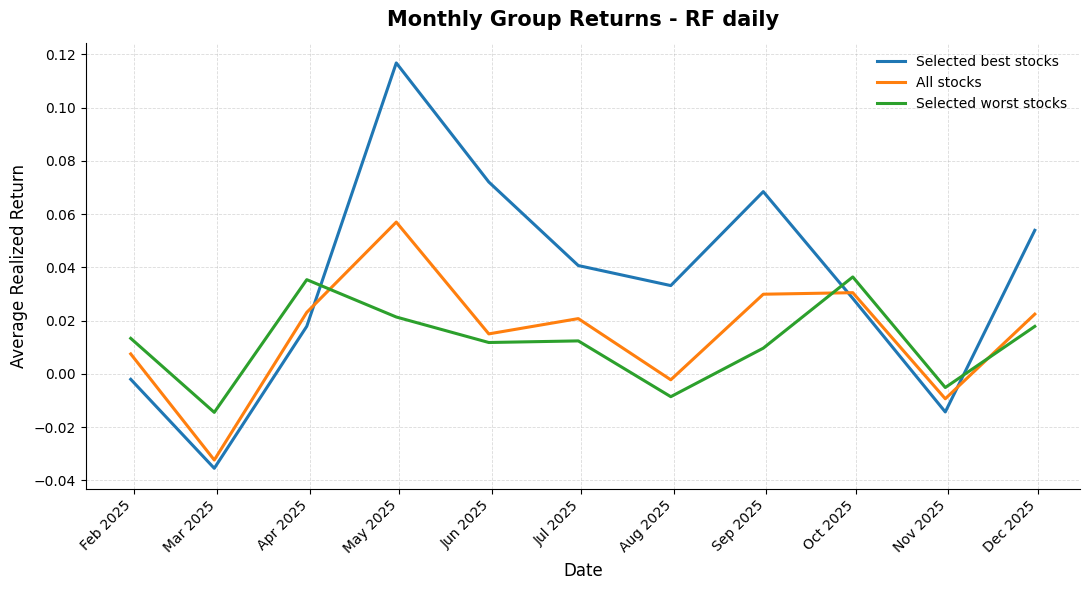

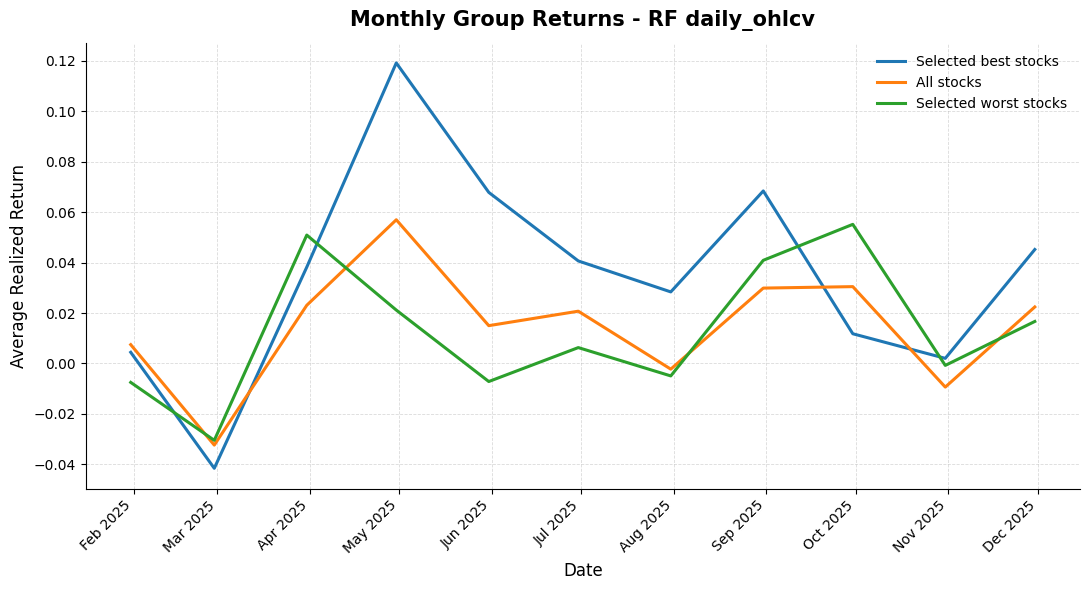

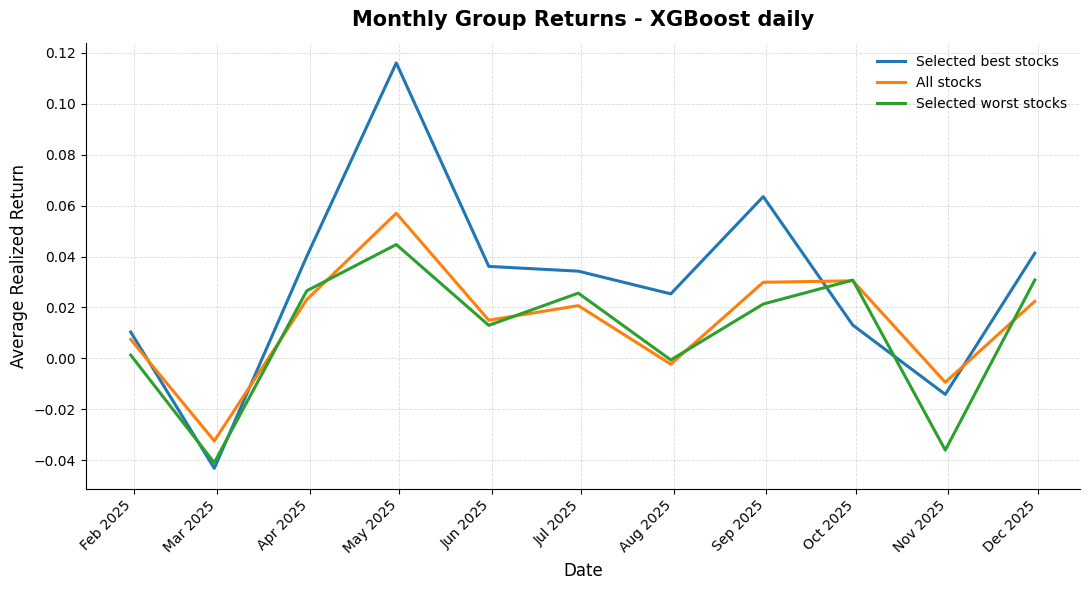

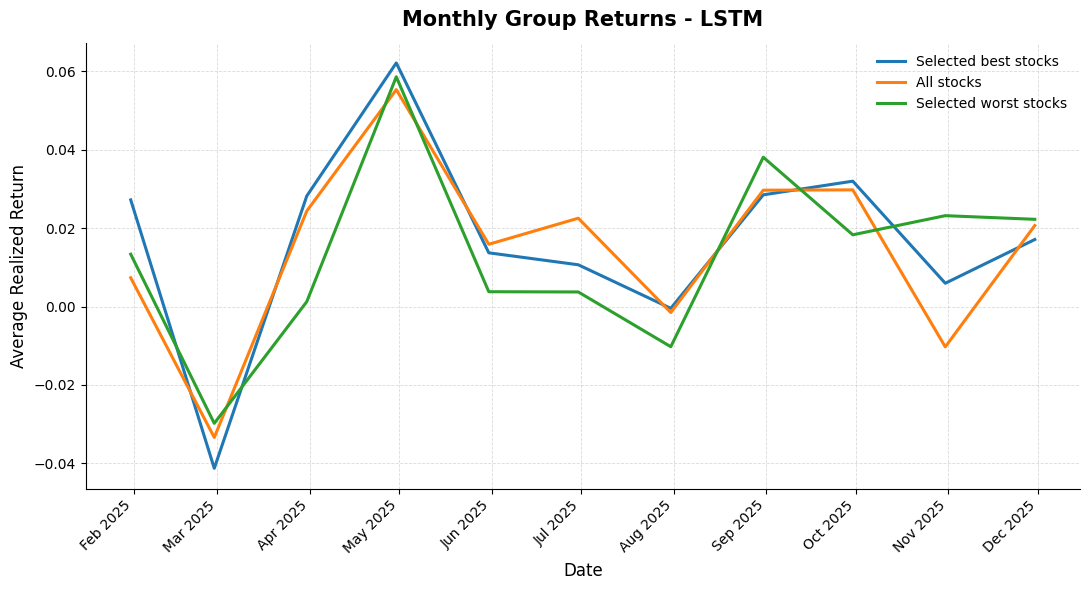

In [16]:
selected_models = [
    m for m in ["Ridge daily", "RF daily", "RF daily_ohlcv", "XGBoost daily", "LSTM"]
    if m in monthly_spread_results
]

for model_name in selected_models:
    sub = monthly_spread_results[model_name].copy()
    sub["date"] = pd.to_datetime(sub["date"])
    sub = sub.sort_values("date").set_index("date")

    series_map = {
        "Selected best stocks": sub["top_avg_realized_return"],
        "All stocks": sub["all_avg_realized_return"],
        "Selected worst stocks": sub["bottom_avg_realized_return"],
    }

    plot_multi_series(
        series_map=series_map,
        title=f"Monthly Group Returns - {model_name}",
        ylabel="Average Realized Return",
        save_path=str(FIGURES_DIR / f"{model_name.lower().replace(' ', '_')}_monthly_group_returns.png"),
        color_map=final_color_map,
        show=True,
    )

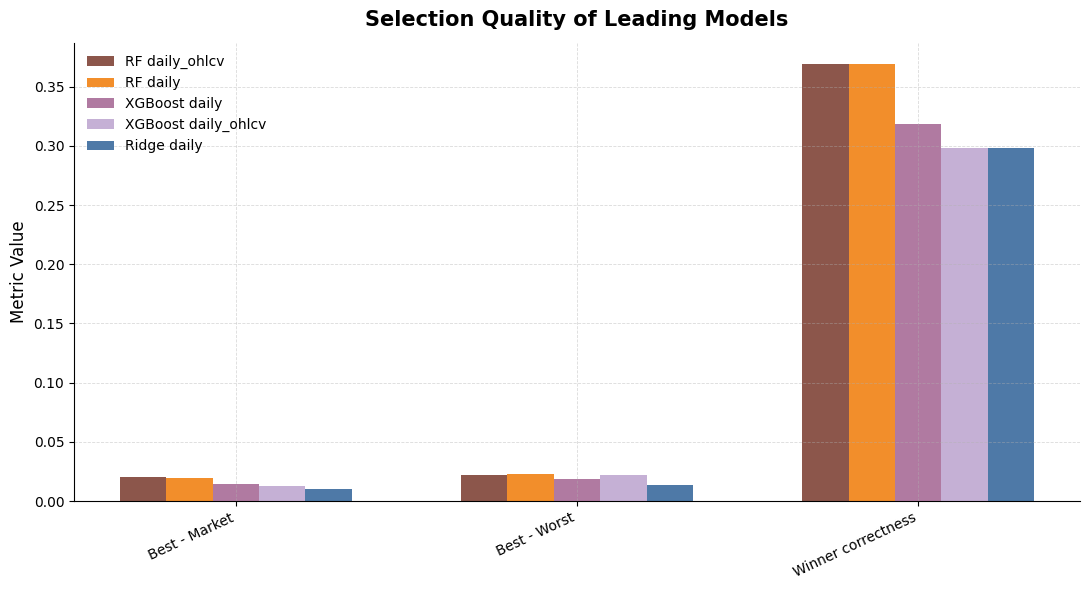

In [17]:
focused_models = [
    m for m in ["RF daily", "RF daily_ohlcv", "XGBoost daily", "XGBoost daily_ohlcv", "Ridge daily"]
    if m in selection_comparison["model"].tolist()
]

focused_df = selection_comparison[
    selection_comparison["model"].isin(focused_models)
].copy()

focused_metric_df = pd.DataFrame(
    {
        "Best - Market": focused_df.set_index("model")[
            "best_stocks_advantage_over_market_avg"
        ],
        "Best - Worst": focused_df.set_index("model")[
            "gap_between_best_and_worst_selected_stocks"
        ],
        "Winner correctness": focused_df.set_index("model")[
            "winner_picking_correctness"
        ],
    }
).T

plot_grouped_metric_bars(
    metric_df=focused_metric_df,
    title="Selection Quality of Leading Models",
    ylabel="Metric Value",
    save_path=str(FIGURES_DIR / "selection_leading_models_grouped.png"),
    color_map=final_color_map,
    show=True,
)

## Interpretation

This notebook compares models on portfolio-selection usefulness rather than raw forecast error alone.

The most important diagnostics are:

- **Best stocks advantage over market average**  
  Shows whether the selected top-ranked stocks actually outperformed the universe.

- **Market advantage over worst stocks**  
  Shows whether the selected worst-ranked stocks underperformed the universe.

- **Gap between best and worst selected stocks**  
  Shows how strongly the model separates the cross-section.

- **Winner-picking correctness**  
  Shows how often the selected best stocks were truly in the actual top-performing group.

- **Loser-picking correctness**  
  Shows how often the selected worst stocks were truly in the actual bottom-performing group.

These diagnostics help identify which models are most useful for practical stock selection, especially for long-only portfolios.